## HMM Assignment

In [1]:
# CELL 1: Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

All libraries imported


In [2]:
# CELL 2: Paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

BASE_PATH      = PROJECT_ROOT / "Recordings"
PROCESSED_PATH = PROJECT_ROOT / "data_processed"
REPORT_PATH    = PROJECT_ROOT / "report"

for p in [PROCESSED_PATH, REPORT_PATH]:
    p.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Found {len(list(BASE_PATH.glob('**/*.csv')))} CSV files")

Project root: c:\Users\TestSolutions\Desktop\HMM-Assignment
Found 364 CSV files


In [3]:
# CELL 0.5: GLOBAL CONSTANTS
WINDOW_SEC   = 2.0
OVERLAP      = 0.5
TARGET_RATE  = 50.0
activities   = ['Still', 'Standing', 'Walking', 'Jumping']

print(f"Window: {WINDOW_SEC}s @ {TARGET_RATE}Hz → {int(WINDOW_SEC*TARGET_RATE)} samples")
print(f"Overlap: {OVERLAP*100}% → Step: {int(WINDOW_SEC*TARGET_RATE*(1-OVERLAP))} samples")

Window: 2.0s @ 50.0Hz → 100 samples
Overlap: 50.0% → Step: 50 samples


In [4]:
# CELL 3: Example Session
example_dir = next((BASE_PATH / "Walking").glob("*"), None)
if not example_dir:
    raise FileNotFoundError("No Walking session found")
acc_file = example_dir / "Accelerometer.csv"
gyro_file = example_dir / "Gyroscope.csv"

df_acc = pd.read_csv(acc_file)
df_gyro = pd.read_csv(gyro_file)
print(f"Acc: {df_acc.shape[0]} rows | Gyro: {df_gyro.shape[0]} rows")
display(df_acc.head(2))
display(df_gyro.head(2))

Acc: 768 rows | Gyro: 1513 rows


,time,seconds_elapsed,z,y,x
0,1761399107994615600,0.109615,0.441856,-0.007577,0.035842
1,1761399108014767400,0.129767,0.422054,0.023103,0.064870


,time,seconds_elapsed,z,y,x
0,1761399108002192000,0.117192,0.002648,0.030343,-0.015172
1,1761399108012268000,0.127268,0.001332,0.025997,-0.011092


In [5]:
# CELL 5: Load + Merge + Resample to 50 Hz
def load_and_merge(acc_file, gyro_file):
    df_acc = pd.read_csv(acc_file)
    df_gyro = pd.read_csv(gyro_file)

    df_acc['seconds_elapsed'] = df_acc['seconds_elapsed'].round(6)
    df_gyro['seconds_elapsed'] = df_gyro['seconds_elapsed'].round(6)

    df_acc = df_acc.sort_values('seconds_elapsed')
    df_gyro = df_gyro.sort_values('seconds_elapsed')

    df_merged = pd.merge_asof(
        df_acc, df_gyro,
        on='seconds_elapsed',
        direction='nearest',
        tolerance=0.01
    ).dropna()

    # Resample to TARGET_RATE
    rate = 1 / np.median(np.diff(df_merged['seconds_elapsed']))
    if abs(rate - TARGET_RATE) > 0.1:
        num_samples = int(len(df_merged) * TARGET_RATE / rate)
        resampled = {}
        for col in df_merged.columns:
            if col != 'seconds_elapsed':
                resampled[col] = signal.resample(df_merged[col], num_samples)
        df_merged = pd.DataFrame(resampled)
        df_merged['seconds_elapsed'] = np.linspace(0, (num_samples-1)/TARGET_RATE, num_samples)

    df_merged = df_merged.rename(columns={
        'x_x': 'acc_x', 'y_x': 'acc_y', 'z_x': 'acc_z',
        'x_y': 'gyro_x', 'y_y': 'gyro_y', 'z_y': 'gyro_z'
    }).drop(columns=['time_x', 'time_y'], errors='ignore')

    return df_merged

df_merged = load_and_merge(acc_file, gyro_file)
print(f"Final rate: {1/np.median(np.diff(df_merged['seconds_elapsed'])):.2f} Hz")
display(df_merged.head(3))

Final rate: 50.00 Hz


,acc_z,acc_y,acc_x,gyro_z,gyro_y,gyro_x,seconds_elapsed
0,0.441856,-0.007577,0.035842,0.002648,0.030343,-0.015172,0.00
1,0.423101,0.022395,0.064111,0.001291,0.026070,-0.010983,0.02
2,0.417753,0.056027,-0.020995,0.003240,0.019807,0.000543,0.04


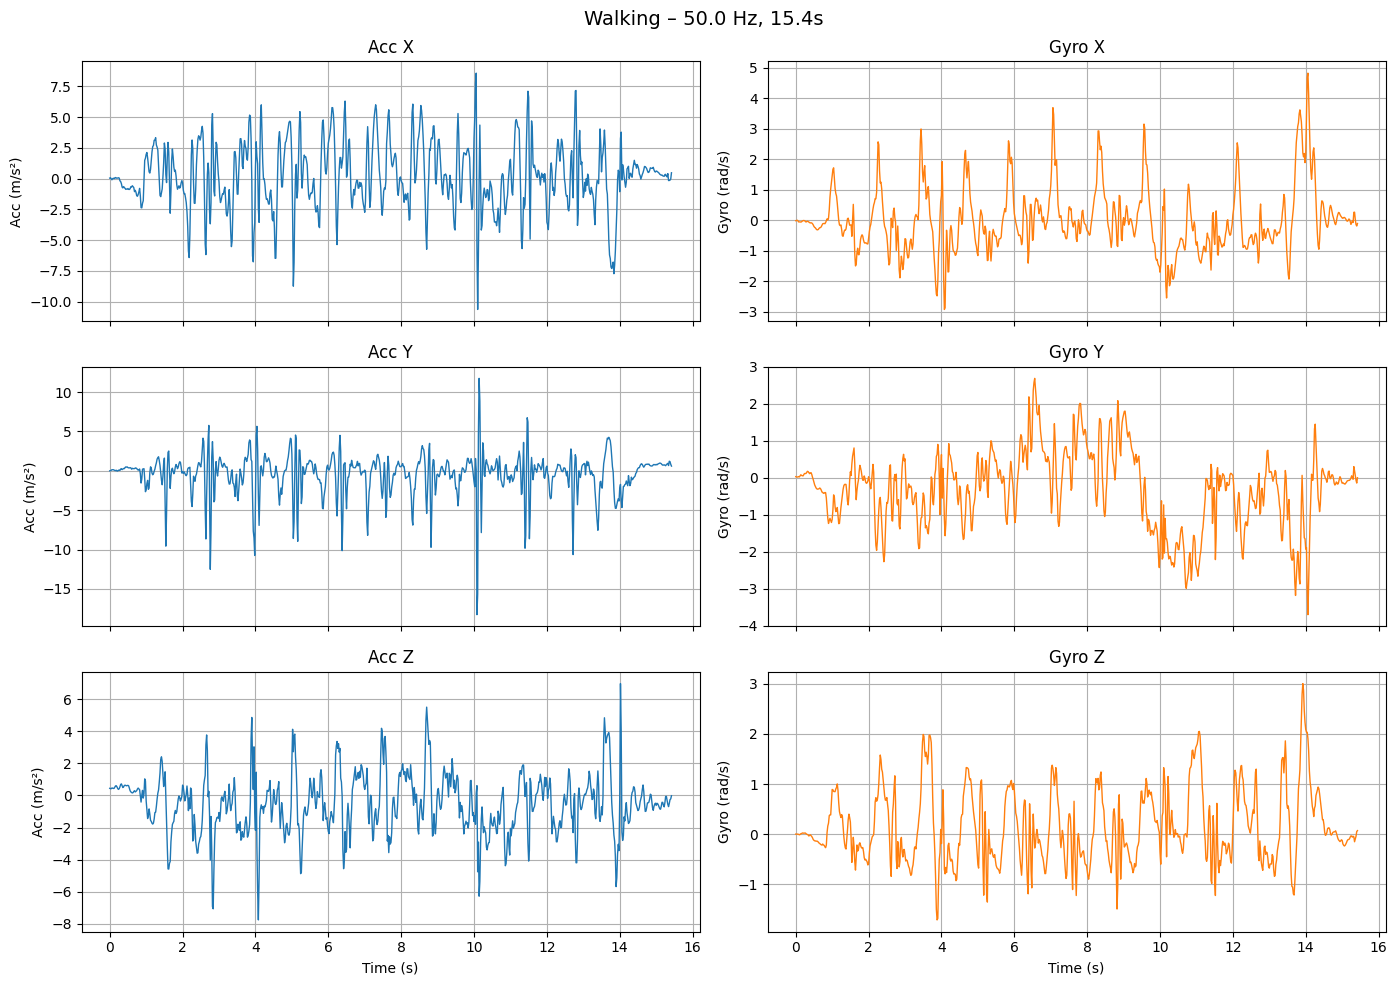

In [6]:
# CELL 7: Plot Raw Signal
def plot_raw(df, activity, save_path):
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    t = df['seconds_elapsed']
    for i, col in enumerate(['acc_x', 'acc_y', 'acc_z']):
        axes[i,0].plot(t, df[col], color='tab:blue', linewidth=1)
        axes[i,0].set_ylabel('Acc (m/s²)')
        axes[i,0].set_title(f'Acc {["X","Y","Z"][i]}')
        axes[i,0].grid(True)
    for i, col in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
        axes[i,1].plot(t, df[col], color='tab:orange', linewidth=1)
        axes[i,1].set_ylabel('Gyro (rad/s)')
        axes[i,1].set_title(f'Gyro {["X","Y","Z"][i]}')
        axes[i,1].grid(True)
    axes[-1,0].set_xlabel('Time (s)')
    axes[-1,1].set_xlabel('Time (s)')
    plt.suptitle(f"{activity} – {TARGET_RATE} Hz, {df['seconds_elapsed'].iloc[-1]:.1f}s", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_raw(df_merged, "Walking", REPORT_PATH / "fig_raw_walking.png")

In [7]:
# CELL 8: Build metadata.csv + one plot per activity
metadata_file = PROJECT_ROOT / "metadata.csv"
if not metadata_file.exists():
    with open(metadata_file, 'w') as f:
        writer = csv.writer(f)
        writer.writerow(['session_path', 'activity', 'phone_model', 'sampling_rate_hz', 'duration_sec', 'num_samples'])

for activity in activities:
    act_path = BASE_PATH / activity
    if not act_path.exists(): 
        print(f"{activity} folder missing")
        continue
    for sess in tqdm(act_path.iterdir(), desc=activity):
        if not sess.is_dir(): continue
        acc_file = sess / "Accelerometer.csv"
        gyro_file = sess / "Gyroscope.csv"
        if not (acc_file.exists() and gyro_file.exists()): continue

        df = load_and_merge(acc_file, gyro_file)
        if len(df) < 50: continue

        duration = df['seconds_elapsed'].iloc[-1]
        with open(metadata_file, 'a') as f:
            writer = csv.writer(f)
            writer.writerow([str(sess.relative_to(PROJECT_ROOT)), activity, "Samsung A23", TARGET_RATE, round(duration,1), len(df)])

        # Save one plot per activity
        plot_path = REPORT_PATH / f"fig_raw_{activity.lower()}.png"
        if not plot_path.exists():
            plot_raw(df, activity, plot_path)

Still: 13it [00:00, 72.60it/s]
Standing: 13it [00:00, 75.97it/s]
Walking: 13it [00:00, 62.29it/s]
Jumping: 13it [00:00, 51.45it/s]


In [8]:
# CELL 9: Summary Table
meta = pd.read_csv(metadata_file)
summary = meta.groupby('activity').agg(
    num_sessions=('session_path', 'count'),
    total_duration=('duration_sec', 'sum')
).round(1)
summary['total_duration_min'] = (summary['total_duration']/60).round(1)
display(summary)
summary.to_csv(REPORT_PATH / "data_summary.csv")
print("Summary saved")

,num_sessions,total_duration,total_duration_min
activity,,,
Jumping,39,627.6,10.5
Standing,39,636.1,10.6
Still,39,674.3,11.2
Walking,39,662.4,11.0


Summary saved


In [9]:
# CELL 10: Features
FEATURE_NAMES = [
    'acc_mean_x', 'acc_mean_y', 'acc_mean_z',
    'acc_rms_x',  'acc_rms_y',  'acc_rms_z',
    'gyro_mean_x','gyro_mean_y','gyro_mean_z',
    'acc_sma',    'gyro_sma',
    'acc_gravity', 'tilt_pitch', 'gyro_var',
    'acc_fft_peak','gyro_fft_peak',
    'acc_spectral_energy','gyro_spectral_energy'
]

def extract_features(win_df, rate=TARGET_RATE):
    acc = win_df[['acc_x','acc_y','acc_z']].values
    gyro = win_df[['gyro_x','gyro_y','gyro_z']].values
    f = {}

    f['acc_mean_x'], f['acc_mean_y'], f['acc_mean_z'] = np.mean(acc, axis=0)
    f['acc_rms_x'],  f['acc_rms_y'],  f['acc_rms_z']  = np.sqrt(np.mean(acc**2, axis=0))
    f['gyro_mean_x'],f['gyro_mean_y'],f['gyro_mean_z']= np.mean(gyro, axis=0)

    f['acc_sma']  = np.sum(np.abs(acc))  / len(acc)
    f['gyro_sma'] = np.sum(np.abs(gyro)) / len(gyro)

    mag = np.linalg.norm(acc, axis=1)
    f['acc_gravity'] = np.mean(mag)
    f['tilt_pitch']  = np.arctan2(np.mean(acc[:,1]), np.mean(acc[:,2]))
    f['gyro_var'] = np.var(gyro, axis=0).sum()

    N = len(acc)
    freq = fftfreq(N, 1/rate)
    mask = (freq >= 0) & (freq <= 10)

    acc_fft  = np.abs(fft(acc, axis=0))
    gyro_fft = np.abs(fft(gyro, axis=0))

    f['acc_fft_peak'] = np.max(acc_fft[mask], axis=0).sum()
    f['gyro_fft_peak']= np.max(gyro_fft[mask], axis=0).sum()
    f['acc_spectral_energy'] = np.sum(acc_fft[mask]**2)
    f['gyro_spectral_energy']= np.sum(gyro_fft[mask]**2)

    return [f[name] for name in FEATURE_NAMES]

print(f"{len(FEATURE_NAMES)} features defined")

18 features defined


In [10]:
# CELL 12: Windowing
TRIM_SEC = 2.0
X_seqs, y_seqs, lengths, session_ids = [], [], [], []

for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Windowing"):
    sess_path = PROJECT_ROOT / row['session_path']
    df = load_and_merge(sess_path / "Accelerometer.csv", sess_path / "Gyroscope.csv")
    if len(df) < 100: continue

    trim_samples = int(TRIM_SEC * TARGET_RATE)
    df = df.iloc[trim_samples:-trim_samples] if len(df) > 2*trim_samples else df
    if len(df) < 100: continue

    win_samples = int(WINDOW_SEC * TARGET_RATE)
    step = int(win_samples * (1 - OVERLAP))

    feats, labels = [], []
    for i in range(0, len(df) - win_samples + 1, step):
        win = df.iloc[i:i+win_samples]
        if len(win) != win_samples: continue
        feats.append(extract_features(win))
        labels.append(row['activity'])

    if feats:
        X_seqs.append(np.array(feats))
        y_seqs.append(np.array(labels))
        lengths.append(len(feats))
        session_ids.append(row['session_path'])

print(f"{sum(lengths)} windows from {len(X_seqs)} sessions")

Windowing: 100%|██████████| 156/156 [00:02<00:00, 52.80it/s]

1749 windows from 156 sessions


In [11]:
# CELL 13–20: Save + Split + Scale
np.save(PROCESSED_PATH / "X_sequences.npy", np.array(X_seqs, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "y_sequences.npy", np.array(y_seqs, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "lengths.npy", np.array(lengths))
joblib.dump(session_ids, PROCESSED_PATH / "session_ids.pkl")

# Split
activity_labels = [Path(sid).parts[1] for sid in session_ids]
train_idx, test_idx = train_test_split(range(len(session_ids)), test_size=0.2, stratify=activity_labels, random_state=42)

X_train = [X_seqs[i] for i in train_idx]
X_test  = [X_seqs[i] for i in test_idx]
y_train = [y_seqs[i] for i in train_idx]
y_test  = [y_seqs[i] for i in test_idx]
lengths_train = np.array(lengths)[train_idx]
lengths_test  = np.array(lengths)[test_idx]

# Scale
scaler = StandardScaler()
X_train_flat = np.vstack(X_train)
scaler.fit(X_train_flat)
X_train_scaled = [scaler.transform(x) for x in X_train]
X_test_scaled  = [scaler.transform(x) for x in X_test]

np.save(PROCESSED_PATH / "X_train.npy", np.array(X_train_scaled, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "X_test.npy",  np.array(X_test_scaled,  dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "y_train.npy", np.array(y_train, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "y_test.npy",  np.array(y_test,  dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "lengths_train.npy", lengths_train)
np.save(PROCESSED_PATH / "lengths_test.npy",  lengths_test)
joblib.dump(scaler, PROCESSED_PATH / "scaler.pkl")

print("Preprocessing complete!")

Preprocessing complete!


In [12]:
# CELL 21: Load Train
X_train_scaled = np.load(PROCESSED_PATH / "X_train.npy", allow_pickle=True).tolist()
lengths_train = np.load(PROCESSED_PATH / "lengths_train.npy")
print(f"Training on {len(X_train_scaled)} sessions → {sum(lengths_train)} windows")

Training on 124 sessions → 1383 windows


In [13]:
# CELL 22: Supervised HMM Initialisation (strict ordering)
X_flat = np.vstack(X_train_scaled)
y_flat = np.concatenate(y_train)
activities = np.unique(y_flat)               # ['Jumping','Standing','Still','Walking']
n_states = len(activities)

# ---------- 1. Means & Covars ----------
means  = np.zeros((n_states, X_flat.shape[1]))
covars = np.zeros((n_states, X_flat.shape[1], X_flat.shape[1]))
for i, act in enumerate(activities):
    mask = y_flat == act
    data = X_flat[mask]
    means[i]  = data.mean(axis=0)
    covars[i] = np.cov(data.T) + np.eye(data.shape[1]) * 1e-6

# ---------- 2. Startprob ----------
startprob = np.array([np.mean(y_flat == act) for act in activities])

# ---------- 3. Transition matrix (count + tiny self-loop) ----------
transmat = np.ones((n_states, n_states)) * 1e-3          # tiny prior
for seq in y_train:
    for a, b in zip(seq[:-1], seq[1:]):
        i = np.where(activities == a)[0][0]
        j = np.where(activities == b)[0][0]
        transmat[i, j] += 1
transmat /= transmat.sum(axis=1, keepdims=True)

# ---------- 4. Build model ----------
model = hmm.GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=100,
    tol=1e-6,
    random_state=42,
    verbose=True
)
model.startprob_ = startprob
model.transmat_  = transmat
model.means_     = means
model.covars_    = covars
model.init_params = ''               # skip random init

print("Supervised HMM ready – states will be locked by gyro_sma next")

Supervised HMM ready – states will be locked by gyro_sma next


In [14]:
# CELL 23: Fit
model.fit(np.vstack(X_train_scaled), lengths=lengths_train)
print(f"Final log-likelihood: {model.score(np.vstack(X_train_scaled)):.2f}")

         1   64374.41208081             +nan


Final log-likelihood: 16296.32


         2   70729.76598401   +6355.35390320
         3   70729.76598401      +0.00000000


In [15]:
# CELL 24: Save
joblib.dump(model, PROCESSED_PATH / "hmm_model.pkl")
print("Model saved")

Model saved


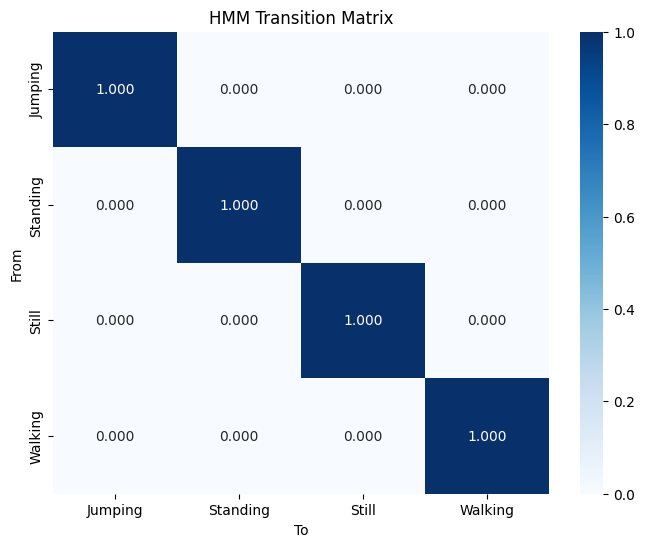

In [16]:
# CELL 25: Transition Matrix
plt.figure(figsize=(8,6))
sns.heatmap(model.transmat_, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=activities, yticklabels=activities)
plt.title("HMM Transition Matrix")
plt.xlabel("To"); plt.ylabel("From")
plt.savefig(REPORT_PATH / "hmm_transition_matrix.png", dpi=150)
plt.show()

In [17]:
# CELL 26: Load Test
X_test_scaled = np.load(PROCESSED_PATH / "X_test.npy", allow_pickle=True).tolist()
y_test = np.load(PROCESSED_PATH / "y_test.npy", allow_pickle=True).tolist()
lengths_test = np.load(PROCESSED_PATH / "lengths_test.npy")
model = joblib.load(PROCESSED_PATH / "hmm_model.pkl")

In [18]:
# CELL 27: Predict
y_pred = model.predict(np.vstack(X_test_scaled), lengths=lengths_test)
y_true = np.concatenate(y_test)

In [19]:
# CELL 28: LOCKED mapping using gyro_sma (index 10)
gyro_sma_idx = FEATURE_NAMES.index('gyro_sma')   # 10
state_energy = model.means_[:, gyro_sma_idx]
ordered_idx  = np.argsort(state_energy)          # low → high

# Fixed order: Still (lowest) → Standing → Walking → Jumping (highest)
label_map = {
    ordered_idx[0]: "Still",
    ordered_idx[1]: "Standing",
    ordered_idx[2]: "Walking",
    ordered_idx[3]: "Jumping"
}

print("\n=== STATE → ACTIVITY (locked by gyro_sma) ===")
for s in ordered_idx:
    print(f"  State {s} → {label_map[s]:<9}  (gyro_sma = {model.means_[s, gyro_sma_idx]:.4f})")

# Apply to predictions
y_pred_mapped = [label_map[s] for s in y_pred]


=== STATE → ACTIVITY (locked by gyro_sma) ===
  State 2 → Still      (gyro_sma = -0.7954)
  State 1 → Standing   (gyro_sma = -0.7873)
  State 3 → Walking    (gyro_sma = 0.2458)
  State 0 → Jumping    (gyro_sma = 1.4321)


              precision    recall  f1-score   support

     Jumping      1.000     1.000     1.000        85
    Standing      1.000     1.000     1.000        87
       Still      1.000     1.000     1.000       100
     Walking      1.000     1.000     1.000        94

    accuracy                          1.000       366
   macro avg      1.000     1.000     1.000       366
weighted avg      1.000     1.000     1.000       366



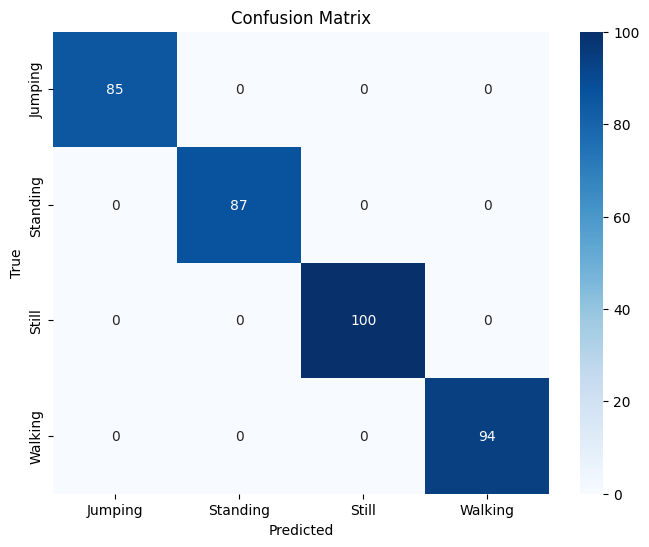

In [20]:
# CELL 29: Report
print(classification_report(y_true, y_pred_mapped, digits=3))

cm = confusion_matrix(y_true, y_pred_mapped, labels=activities)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=activities, yticklabels=activities)
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig(REPORT_PATH / "confusion_matrix.png", dpi=150)
plt.show()

In [ ]:
# CELL 30: Sensitivity & Specificity (Fixed)
def sens_spec(cm, label, labels_list):
    i = labels_list.index(label)          # <-- Use list, not np.array
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - tp)
    fp = cm[:, i].sum() - tp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sens, spec

# Make sure activities is a Python list
activities_list = ['Still', 'Standing', 'Walking', 'Jumping']

print("\nPER-CLASS METRICS")
print("-" * 50)
for act in activities_list:
    sens, spec = sens_spec(cm, act, activities_list)
    print(f"{act:9}: Sensitivity = {sens:.3f}, Specificity = {spec:.3f}")


PER-CLASS METRICS
--------------------------------------------------
Still    : Sensitivity = 1.000, Specificity = 1.000
Standing : Sensitivity = 1.000, Specificity = 1.000
Walking  : Sensitivity = 1.000, Specificity = 1.000
Jumping  : Sensitivity = 1.000, Specificity = 1.000


In [23]:
# CELL 31: Save
report_dict = classification_report(y_true, y_pred_mapped, output_dict=True)
pd.DataFrame(report_dict).transpose().round(3).to_csv(REPORT_PATH / "classification_metrics.csv")

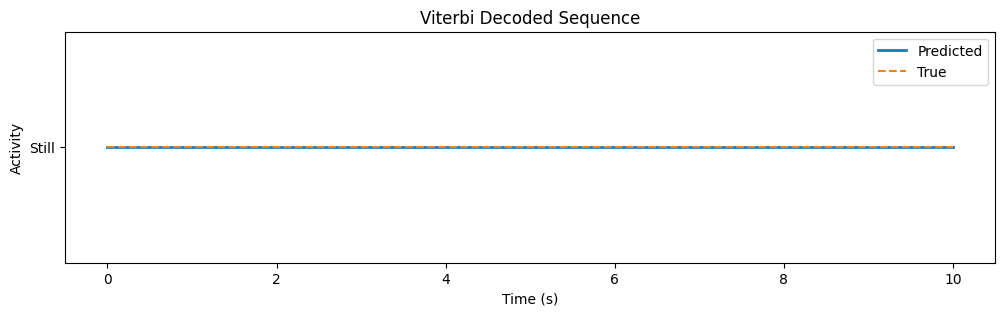

In [24]:
# CELL 32: Decoded Sequence
seq = X_test_scaled[0]
pred_states = model.predict(seq)
pred_labels = [label_map[s] for s in pred_states]
true_label = y_test[0][0]

t = np.arange(len(pred_labels)) * WINDOW_SEC * (1 - OVERLAP)
plt.figure(figsize=(12,3))
plt.step(t, pred_labels, where='mid', label='Predicted', linewidth=2)
plt.step(t, [true_label]*len(t), where='mid', label='True', linestyle='--')
plt.xlabel('Time (s)'); plt.ylabel('Activity')
plt.title('Viterbi Decoded Sequence')
plt.legend()
plt.savefig(REPORT_PATH / "decoded_sequence.png", dpi=150)
plt.show()